In [1]:
# ================================================================
# sdp_core.py
# ================================================================
# Stochastic Dynamic Programming (SDP) solver for sequential
# drilling campaign analysis.
# Author: Wellington (PhD project)
# ================================================================

import numpy as np
import itertools
import time
from typing import List, Dict, Tuple, Any


class SequentialDrillingSDP:
    """
    Class that implements a Stochastic Dynamic Programming (SDP)
    model for sequential drilling campaigns with correlated wells.
    """

    def __init__(self,
                 num_wells: int,
                 revenues: List[float],
                 drilling_cost: float = 0.0,
                 correlation_strength: float = 0.3,
                 num_simulations: int = 1000,
                 random_seed: int = None):
        """
        Initialize the Sequential Drilling SDP solver.
        """
        self.num_wells = num_wells
        self.num_states = len(revenues)
        self.revenues = revenues
        self.drilling_cost = drilling_cost
        self.correlation_strength = correlation_strength
        self.num_simulations = num_simulations
        self.random_seed = random_seed if random_seed is not None else int(time.time())
        self.rng = np.random.RandomState(self.random_seed)

        # Separate caches for values and conditional probabilities
        self.value_cache = {}
        self.conditional_cache = {}

        # Initialize random marginal probabilities
        self.marginal_probs = self._initialize_random_marginal_probs()

        # Build correlated joint probability distribution (JPD)
        self.jpd = self._initialize_jpd_with_correlation()

    # ------------------------------------------------------------------
    # Initialization Methods
    # ------------------------------------------------------------------

    def _initialize_random_marginal_probs(self) -> List[np.ndarray]:
        """Initialize random marginal probabilities for each well."""
        probs = []
        for _ in range(self.num_wells):
            alpha = self.rng.uniform(0.5, 3, self.num_states)
            p = self.rng.dirichlet(alpha)
            probs.append(p)
        return probs

    def _initialize_jpd_with_correlation(self) -> np.ndarray:
        """
        Initialize a Joint Probability Distribution (JPD) with
        spatial correlation among wells.
        """
        positions = np.linspace(0, 1, self.num_wells)
        covariance_matrix = np.zeros((self.num_wells, self.num_wells))

        # Exponential spatial decay of correlation
        for i in range(self.num_wells):
            for j in range(self.num_wells):
                distance = abs(positions[i] - positions[j])
                covariance_matrix[i, j] = np.exp(-distance / 0.3) * self.correlation_strength

        jpd = np.zeros([self.num_states] * self.num_wells)

        # Construct correlated JPD through approximate multiplicative rule
        for indices in itertools.product(*[range(self.num_states) for _ in range(self.num_wells)]):
            prob = 1.0
            for w_idx, state in enumerate(indices):
                base_prob = self.marginal_probs[w_idx][state]
                correlation_factor = 1.0
                for other_idx, other_state in enumerate(indices):
                    if w_idx != other_idx and state == other_state:
                        correlation_factor += covariance_matrix[w_idx, other_idx] * 0.5
                prob *= max(base_prob * correlation_factor, 0.0)
            jpd[indices] = prob

        # Normalize JPD to ensure total probability = 1
        jpd /= jpd.sum()
        return jpd

    # ------------------------------------------------------------------
    # Probability Updating (Bayesian)
    # ------------------------------------------------------------------

    def get_conditional_probs(self,
                              observed_wells: Dict[int, int],
                              remaining_wells: List[int]) -> Dict[int, np.ndarray]:
        """
        Compute conditional probabilities for remaining wells
        given observed wells using the full JPD.
        """
        cache_key = (tuple(sorted(observed_wells.items())), tuple(sorted(remaining_wells)))
        if cache_key in self.conditional_cache:
            return self.conditional_cache[cache_key]

        conditional_probs = {}

        for target_well in remaining_wells:
            # Sum over all combinations consistent with observations
            target_probs = np.zeros(self.num_states)
            evidence_prob = 0.0

            for full_state in itertools.product(*[range(self.num_states)] * self.num_wells):
                consistent = all(full_state[w] == s for w, s in observed_wells.items())
                if consistent:
                    prob = self.jpd[full_state]
                    evidence_prob += prob
                    target_state = full_state[target_well]
                    target_probs[target_state] += prob

            if evidence_prob > 0:
                target_probs /= evidence_prob
            else:
                target_probs = self.marginal_probs[target_well]

            conditional_probs[target_well] = target_probs

        self.conditional_cache[cache_key] = conditional_probs
        return conditional_probs

    # ------------------------------------------------------------------
    # Value Functions
    # ------------------------------------------------------------------

    def calculate_expected_value(self, conditional_probs: np.ndarray) -> float:
        """Compute the expected value given a conditional probability vector."""
        return np.sum(conditional_probs * (np.array(self.revenues) - self.drilling_cost))

    # ------------------------------------------------------------------
    # Bellman Equation Solver
    # ------------------------------------------------------------------

    def solve_sdp(self) -> Tuple[float, Dict]:
        """Solve the SDP via recursive Bellman equation."""

        def bellman(perforated_wells: Dict[int, int], remaining_wells: List[int]) -> Tuple[float, int]:
            if not remaining_wells:
                return 0.0, -1

            cache_key = (tuple(sorted(perforated_wells.items())), tuple(sorted(remaining_wells)))
            if cache_key in self.value_cache:
                return self.value_cache[cache_key]

            conditional_probs = self.get_conditional_probs(perforated_wells, remaining_wells)
            best_value = -np.inf
            best_action = -1

            for next_well in remaining_wells:
                well_ev = 0.0
                probs = conditional_probs[next_well]

                for outcome in range(self.num_states):
                    prob = probs[outcome]
                    if prob > 0:
                        reward = self.revenues[outcome] - self.drilling_cost
                        new_perf = perforated_wells.copy()
                        new_perf[next_well] = outcome
                        new_remaining = [w for w in remaining_wells if w != next_well]
                        continuation_value, _ = bellman(new_perf, new_remaining)
                        well_ev += prob * (reward + continuation_value)

                if well_ev > best_value:
                    best_value = well_ev
                    best_action = next_well

            self.value_cache[cache_key] = (best_value, best_action)
            return best_value, best_action

        # Initial Bellman call
        initial_value, first_action = bellman({}, list(range(self.num_wells)))

        # Reconstruct full policy tree
        policy = self._reconstruct_policy()
        return initial_value, policy

    def _reconstruct_policy(self) -> Dict:
        """Reconstruct the full optimal policy tree from cached Bellman results."""
        policy = {}

        def traverse(perforated_wells: Dict[int, int], remaining_wells: List[int]):
            if not remaining_wells:
                return
            cache_key = (tuple(sorted(perforated_wells.items())), tuple(sorted(remaining_wells)))
            if cache_key in self.value_cache:
                value, action = self.value_cache[cache_key]
                state_key = tuple(sorted(perforated_wells.items()))
                policy[state_key] = {'action': action, 'value': value}
                if action != -1:
                    for outcome in range(self.num_states):
                        new_perf = perforated_wells.copy()
                        new_perf[action] = outcome
                        new_remaining = [w for w in remaining_wells if w != action]
                        traverse(new_perf, new_remaining)

        traverse({}, list(range(self.num_wells)))
        return policy

    # ------------------------------------------------------------------
    # Simulation Methods
    # ------------------------------------------------------------------

    def sample_outcome(self, probs: np.ndarray) -> int:
        """Sample a well outcome given its probability distribution."""
        return self.rng.choice(len(probs), p=probs)

    def simulate_prior_campaign(self) -> List[float]:
        """Simulate campaign without sequential learning (prior approach)."""
        values = []
        for _ in range(self.num_simulations):
            total_value = 0.0
            for w in range(self.num_wells):
                ev = self.calculate_expected_value(self.marginal_probs[w])
                if ev > 0:
                    outcome = self.sample_outcome(self.marginal_probs[w])
                    total_value += self.revenues[outcome] - self.drilling_cost
            values.append(total_value)
        return values

    def simulate_sequential_campaign(self, policy: Dict) -> List[float]:
        """Simulate campaign following the optimal sequential policy."""
        values = []
        for sim in range(self.num_simulations):
            sim_rng = np.random.RandomState(self.random_seed + sim)
            perf = {}
            remaining = list(range(self.num_wells))
            total_value = 0.0

            while remaining:
                state_key = tuple(sorted(perf.items()))
                if state_key not in policy:
                    break
                action = policy[state_key]['action']
                if action not in remaining:
                    break

                conditional_probs = self.get_conditional_probs(perf, [action])
                probs = conditional_probs[action]
                outcome = sim_rng.choice(len(probs), p=probs)
                reward = self.revenues[outcome] - self.drilling_cost
                total_value += reward

                perf[action] = outcome
                remaining.remove(action)

                next_key = tuple(sorted(perf.items()))
                if next_key in policy and policy[next_key]['value'] <= 0:
                    break

            values.append(total_value)
        return values


In [5]:
# ================================================================
# sdp_visualizer.py
# ================================================================
# Visualization and statistical analysis tools for sequential
# drilling campaign results (SDP framework).
# Author: Wellington (PhD project)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


class DrillingCampaignVisualizer:
    """
    Visualization and statistical analysis class for the
    Sequential Drilling SDP model.
    """

    @staticmethod
    def plot_comprehensive_analysis(analysis_results: dict, num_wells: int):
        """Generate full visual and statistical analysis."""
        prior_sim = analysis_results["prior_simulations"]
        seq_sim = analysis_results["sequential_simulations"]
        well_analysis = analysis_results["well_analysis"]

        fig = plt.figure(figsize=(20, 15))
        fig.suptitle(f"Sequential Drilling Campaign Analysis - {num_wells} Wells",
                     fontsize=16, fontweight="bold", y=0.98)

        # ================================================================
        # 1. Distribution comparison
        # ================================================================
        ax1 = plt.subplot(3, 3, 1)
        bins = np.linspace(min(prior_sim + seq_sim), max(prior_sim + seq_sim), 30)
        ax1.hist(prior_sim, bins=bins, alpha=0.6, color="red",
                 density=True, label="Non-sequential (Prior)")
        ax1.hist(seq_sim, bins=bins, alpha=0.6, color="green",
                 density=True, label="Sequential (SDP)")
        ax1.axvline(np.mean(prior_sim), color="darkred", linestyle="--", label="Prior Mean")
        ax1.axvline(np.mean(seq_sim), color="darkgreen", linestyle="--", label="SDP Mean")
        ax1.set_title("Distribution of Campaign Values (Monte Carlo)")
        ax1.set_xlabel("Campaign Value")
        ax1.set_ylabel("Density")
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # ================================================================
        # 2. Boxplot comparison
        # ================================================================
        ax2 = plt.subplot(3, 3, 2)
        data = [prior_sim, seq_sim]
        box = ax2.boxplot(data, patch_artist=True, tick_labels=["Prior", "Sequential"])
        colors = ["lightcoral", "lightgreen"]
        for patch, color in zip(box["boxes"], colors):
            patch.set_facecolor(color)
        ax2.set_ylabel("Campaign Value")
        ax2.set_title("Boxplot Comparison")
        ax2.grid(True, alpha=0.3)

        # ================================================================
        # 3. Convergence of mean values
        # ================================================================
        ax3 = plt.subplot(3, 3, 3)
        cum_prior = np.cumsum(prior_sim) / np.arange(1, len(prior_sim) + 1)
        cum_seq = np.cumsum(seq_sim) / np.arange(1, len(seq_sim) + 1)
        ax3.plot(cum_prior, label="Prior", color="red", linewidth=2)
        ax3.plot(cum_seq, label="Sequential", color="green", linewidth=2)
        ax3.set_xlabel("Simulations")
        ax3.set_ylabel("Cumulative Mean Value")
        ax3.set_title("Convergence of Expected Value")
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # ================================================================
        # 4. Expected value comparison by well
        # ================================================================
        ax4 = plt.subplot(3, 3, 4)
        wells = [wa["well"] for wa in well_analysis]
        ev_det = [wa["marginal_ev"] for wa in well_analysis]
        ev_sim = [wa["simulated_mean"] for wa in well_analysis]
        x = np.arange(len(wells))
        width = 0.35
        ax4.bar(x - width/2, ev_det, width, label="Deterministic EV", alpha=0.8)
        ax4.bar(x + width/2, ev_sim, width, label="Simulated Mean", alpha=0.8)
        ax4.set_xlabel("Well")
        ax4.set_ylabel("Expected Value")
        ax4.set_title("Deterministic vs Simulated EV by Well")
        ax4.set_xticks(x)
        ax4.set_xticklabels([f"W{i}" for i in wells])
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # ================================================================
        # 5. Success and dry probabilities
        # ================================================================
        ax5 = plt.subplot(3, 3, 5)
        p_success = [wa["probability_success"] for wa in well_analysis]
        p_dry = [wa["probability_dry"] for wa in well_analysis]
        ax5.bar(x, p_success, width, color="green", label="Success Probability", alpha=0.7)
        ax5.bar(x, p_dry, width, bottom=p_success, color="red", label="Dry Probability", alpha=0.7)
        ax5.set_xlabel("Well")
        ax5.set_ylabel("Probability")
        ax5.set_title("Success vs Dry Probabilities")
        ax5.set_xticks(x)
        ax5.set_xticklabels([f"W{i}" for i in wells])
        ax5.legend()
        ax5.grid(True, alpha=0.3)

        # ================================================================
        # 6. Summary bars
        # ================================================================
        ax6 = plt.subplot(3, 3, 6)
        values = [
            analysis_results["prior_ev_simulated"],
            analysis_results["sequential_ev_simulated"],
            analysis_results["voi_simulated"],
            analysis_results["improvement_percent"]
        ]
        labels = ["EV Prior", "EV Sequential", "VOI", "Improvement %"]
        colors = ["red", "green", "orange", "purple"]
        bars = ax6.bar(labels, values, color=colors, alpha=0.7)
        for bar, val in zip(bars, values):
            ax6.text(bar.get_x() + bar.get_width()/2, val + 0.1, f"{val:.2f}",
                     ha="center", va="bottom", fontsize=9)
        ax6.set_ylabel("Value")
        ax6.set_title("Campaign Summary")
        ax6.grid(True, alpha=0.3)

        # ================================================================
        # 7. Risk vs Return
        # ================================================================
        ax7 = plt.subplot(3, 3, 7)
        means = [wa["simulated_mean"] for wa in well_analysis]
        stds = [wa["simulated_std"] for wa in well_analysis]
        scatter = ax7.scatter(means, stds, s=100, c=wells, cmap="viridis", alpha=0.8)
        ax7.set_xlabel("Expected Value")
        ax7.set_ylabel("Standard Deviation (Risk)")
        ax7.set_title("Risk vs Return by Well")
        ax7.grid(True, alpha=0.3)
        for i, (m, s) in enumerate(zip(means, stds)):
            ax7.annotate(f"W{i}", (m, s), xytext=(5, 5), textcoords="offset points")

        # ================================================================
        # 8. VOI Distribution
        # ================================================================
        ax8 = plt.subplot(3, 3, 8)
        voi_dist = np.array(seq_sim) - np.array(prior_sim)
        ax8.hist(voi_dist, bins=30, color="orange", alpha=0.7, density=True)
        ax8.axvline(np.mean(voi_dist), color="darkorange", linestyle="--",
                    linewidth=2, label=f"Mean VOI: {np.mean(voi_dist):.2f}")
        ax8.set_xlabel("Value of Information (VOI)")
        ax8.set_ylabel("Density")
        ax8.set_title("Distribution of VOI")
        ax8.legend()
        ax8.grid(True, alpha=0.3)

        # ================================================================
        # 9. Marginal Probability Matrix
        # ================================================================
        ax9 = plt.subplot(3, 3, 9)
        marginal_data = np.array(analysis_results["marginal_probs"])
        im = ax9.imshow(marginal_data, cmap="YlOrRd", aspect="auto")
        ax9.set_xlabel("Outcome State")
        ax9.set_ylabel("Well")
        ax9.set_title("Marginal Probability Matrix")
        ax9.set_xticks(range(4))
        ax9.set_xticklabels(["#0 Dry", "#1 Poor", "#2 Good", "#3 Excellent"])
        ax9.set_yticks(range(len(wells)))
        ax9.set_yticklabels([f"W{i}" for i in wells])

        for i in range(marginal_data.shape[0]):
            for j in range(marginal_data.shape[1]):
                val = marginal_data[i, j]
                ax9.text(j, i, f"{val:.2f}",
                         ha="center", va="center",
                         color="white" if val > 0.5 else "black")

        plt.colorbar(im, ax=ax9)
        plt.tight_layout()
        plt.show()

        # ================================================================
        # Detailed Statistics
        # ================================================================
        print("\n" + "="*80)
        print("DETAILED STATISTICS")
        print("="*80)
        print(f"\nNon-sequential approach ({len(prior_sim)} simulations):")
        print(f"  Mean: {np.mean(prior_sim):.2f} ± {np.std(prior_sim):.2f}")
        print(f"  Median: {np.median(prior_sim):.2f}")
        print(f"  Range: [{np.min(prior_sim):.2f}, {np.max(prior_sim):.2f}]")

        print(f"\nSequential approach ({len(seq_sim)} simulations):")
        print(f"  Mean: {np.mean(seq_sim):.2f} ± {np.std(seq_sim):.2f}")
        print(f"  Median: {np.median(seq_sim):.2f}")
        print(f"  Range: [{np.min(seq_sim):.2f}, {np.max(seq_sim):.2f}]")

        print(f"\nValue of Information (VOI):")
        print(f"  Mean VOI: {analysis_results['voi_simulated']:.2f}")
        print(f"  Relative Improvement: {analysis_results['improvement_percent']:.1f}%")
        print(f"  Probability(VOI > 0): {(voi_dist > 0).mean()*100:.1f}%")

        print(f"\nPer-well summary:")
        for wa in well_analysis:
            print(f"  Well {wa['well']}: EV={wa['marginal_ev']:.2f}, "
                  f"Success={wa['probability_success']:.1%}, Dry={wa['probability_dry']:.1%}")

        # ================================================================
        # Pandas summary table
        # ================================================================
        df = pd.DataFrame(well_analysis)
        df = df[["well", "marginal_ev", "simulated_mean", "simulated_std",
                 "probability_success", "probability_dry", "should_drill"]]
        df.columns = ["Well", "EV Deterministic", "Mean Simulated", "Std Dev",
                      "P(Success)", "P(Dry)", "Drill?"]

        print("\n" + "="*80)
        print("SUMMARY TABLE")
        print("="*80)
        print(df.to_string(index=False))
        print("="*80)


SEQUENTIAL DRILLING CAMPAIGN ANALYSIS (SDP Framework)


Number of wells:  5
Drilling cost per well (default = 0):  
Spatial correlation strength (0-1, default = 0.3):  0.6
Number of Monte Carlo simulations (default = 1000):  5000



------------------------------------------------------------
 Running analysis for 5 wells
 Drilling cost per well: 0.0
 Correlation strength: 0.6
 Number of Monte Carlo simulations: 5000
------------------------------------------------------------

Randomly generated marginal probabilities:
  Well 0: [0.052 0.207 0.132 0.609] | EV=5.19, Success=74.1%
  Well 1: [0.111 0.009 0.585 0.295] | EV=4.72, Success=88.0%
  Well 2: [0.036 0.777 0.099 0.088] | EV=-2.87, Success=18.7%
  Well 3: [0.232 0.019 0.483 0.265] | EV=2.65, Success=74.9%
  Well 4: [0.009 0.228 0.724 0.038] | EV=2.77, Success=76.2%


Solving optimal policy via Stochastic Dynamic Programming...

Simulating campaigns...
RESULTS SUMMARY
Deterministic Sequential EV (Bellman): 13.69
Simulated Prior EV: 15.56
Simulated Sequential EV: 14.12
Value of Information (VOI): -1.44
Relative Improvement: -9.2%
Optimal first action: Drill well 1
Total runtime: 11.37 seconds


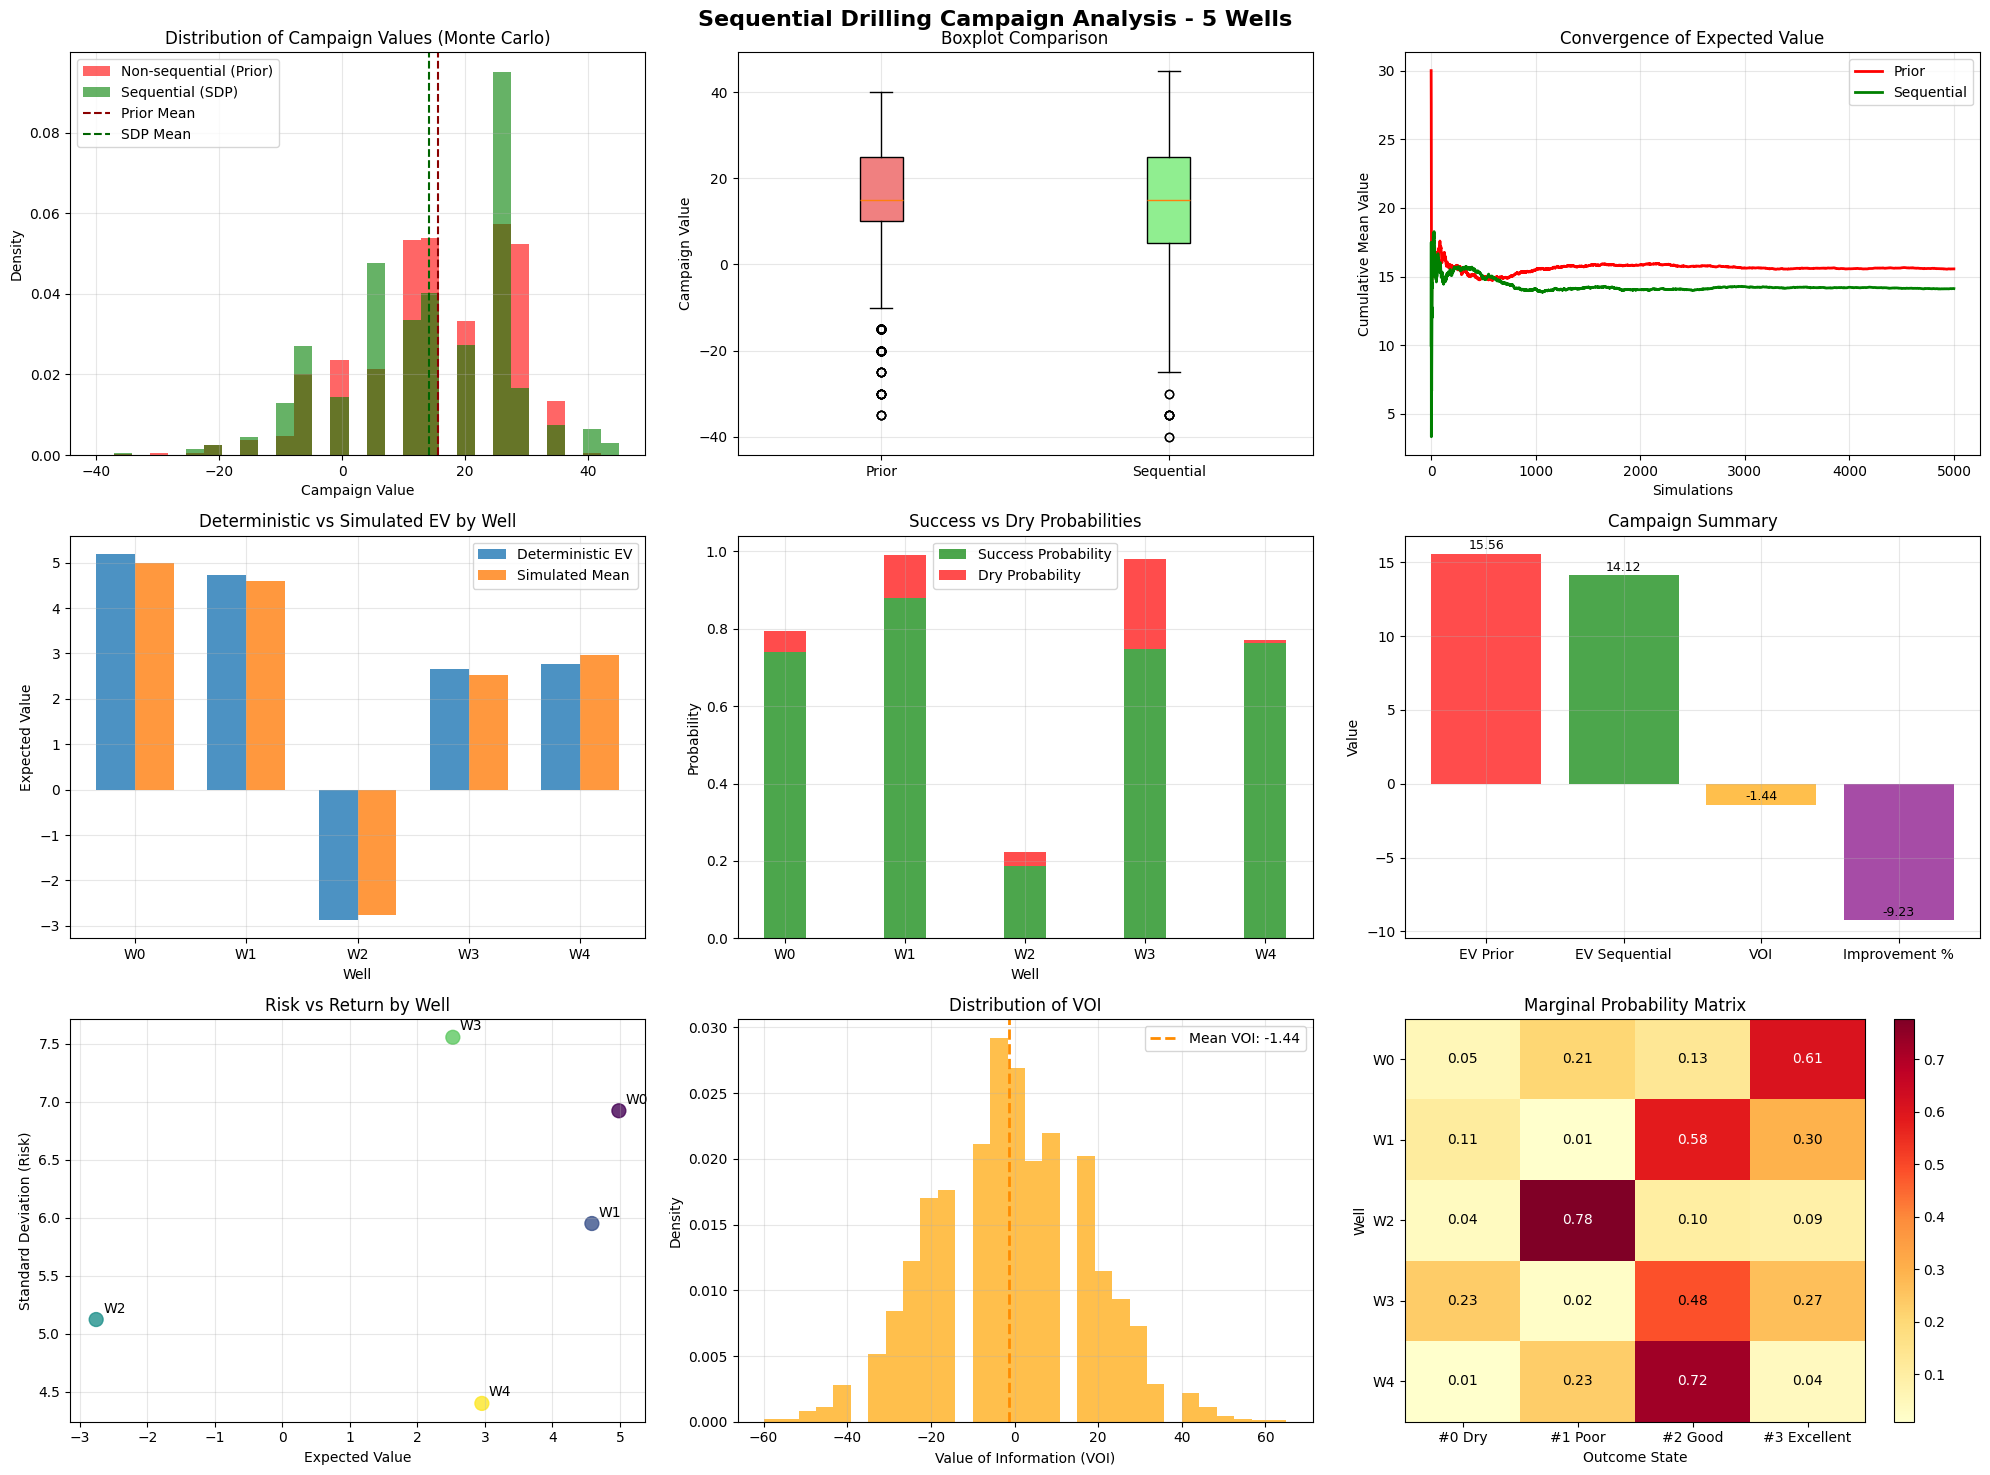


DETAILED STATISTICS

Non-sequential approach (5000 simulations):
  Mean: 15.56 ± 12.43
  Median: 15.00
  Range: [-35.00, 40.00]

Sequential approach (5000 simulations):
  Mean: 14.12 ± 13.52
  Median: 15.00
  Range: [-40.00, 45.00]

Value of Information (VOI):
  Mean VOI: -1.44
  Relative Improvement: -9.2%
  Probability(VOI > 0): 40.5%

Per-well summary:
  Well 0: EV=5.19, Success=74.1%, Dry=5.2%
  Well 1: EV=4.72, Success=88.0%, Dry=11.1%
  Well 2: EV=-2.87, Success=18.7%, Dry=3.6%
  Well 3: EV=2.65, Success=74.9%, Dry=23.2%
  Well 4: EV=2.77, Success=76.2%, Dry=0.9%

SUMMARY TABLE
 Well  EV Deterministic  Mean Simulated  Std Dev  P(Success)   P(Dry)  Drill?
    0          5.190719           4.985 6.922772    0.740831 0.052263    True
    1          4.722084           4.585 5.950023    0.879930 0.110834    True
    2         -2.872819          -2.760 5.121758    0.186956 0.036202   False
    3          2.654595           2.525 7.556413    0.748806 0.232137    True
    4          2.7

In [8]:
# ================================================================
# run_analysis.py
# ================================================================
# Main script to execute Sequential Drilling SDP analysis
# using the core solver and visualizer modules.
# Author: Wellington (PhD project)
# ================================================================

import time
import numpy as np


def run_single_analysis():
    """Execute a full sequential drilling campaign analysis."""
    print("=" * 70)
    print("SEQUENTIAL DRILLING CAMPAIGN ANALYSIS (SDP Framework)")
    print("=" * 70)

    # ----------------------------------------------------------------------
    # User parameters
    # ----------------------------------------------------------------------
    num_wells = int(input("Number of wells: ") or "4")
    drilling_cost = float(input("Drilling cost per well (default = 0): ") or "0")
    correlation_strength = float(input("Spatial correlation strength (0-1, default = 0.3): ") or "0.3")
    num_simulations = int(input("Number of Monte Carlo simulations (default = 1000): ") or "1000")

    print("\n" + "-" * 60)
    print(f" Running analysis for {num_wells} wells")
    print(f" Drilling cost per well: {drilling_cost}")
    print(f" Correlation strength: {correlation_strength}")
    print(f" Number of Monte Carlo simulations: {num_simulations}")
    print("-" * 60 + "\n")

    revenues = [-10, -5, 5, 10]

    # ----------------------------------------------------------------------
    # Initialize the SDP solver
    # ----------------------------------------------------------------------
    solver = SequentialDrillingSDP(
        num_wells=num_wells,
        revenues=revenues,
        drilling_cost=drilling_cost,
        correlation_strength=correlation_strength,
        num_simulations=num_simulations
    )

    # Display marginal probabilities
    print("Randomly generated marginal probabilities:")
    for i, p in enumerate(solver.marginal_probs):
        ev = solver.calculate_expected_value(p)
        success_prob = sum(p[2:])  # states #2 and #3 are "good" and "excellent"
        print(f"  Well {i}: {p.round(3)} | EV={ev:.2f}, Success={success_prob:.1%}")
    print("\n")

    # ----------------------------------------------------------------------
    # Run the full analysis
    # ----------------------------------------------------------------------
    start_time = time.time()

    print("Solving optimal policy via Stochastic Dynamic Programming...")
    sdp_value, policy = solver.solve_sdp()

    print("\nSimulating campaigns...")
    prior_values = solver.simulate_prior_campaign()
    seq_values = solver.simulate_sequential_campaign(policy)

    # ----------------------------------------------------------------------
    # Build analysis results
    # ----------------------------------------------------------------------
    prior_ev = np.mean(prior_values)
    seq_ev = np.mean(seq_values)
    voi = seq_ev - prior_ev

    well_analysis = []
    for w in range(num_wells):
        marginal_ev = solver.calculate_expected_value(solver.marginal_probs[w])
        samples = [solver.sample_outcome(solver.marginal_probs[w]) for _ in range(1000)]
        revenues_sampled = [revenues[s] - drilling_cost for s in samples]
        well_analysis.append({
            "well": w,
            "marginal_ev": marginal_ev,
            "simulated_mean": np.mean(revenues_sampled),
            "simulated_std": np.std(revenues_sampled),
            "should_drill": marginal_ev > 0,
            "probability_dry": solver.marginal_probs[w][0],
            "probability_success": sum(solver.marginal_probs[w][2:]),
        })

    analysis_results = {
        "sequential_ev_deterministic": sdp_value,
        "sequential_ev_simulated": seq_ev,
        "prior_ev_simulated": prior_ev,
        "voi_simulated": voi,
        "improvement_percent": (voi / prior_ev * 100) if prior_ev != 0 else 0,
        "policy": policy,
        "well_analysis": well_analysis,
        "marginal_probs": solver.marginal_probs,
        "prior_simulations": prior_values,
        "sequential_simulations": seq_values,
        "random_seed": solver.random_seed
    }

    end_time = time.time()

    # ----------------------------------------------------------------------
    # Print results summary
    # ----------------------------------------------------------------------
    print("=" * 70)
    print("RESULTS SUMMARY")
    print("=" * 70)
    print(f"Deterministic Sequential EV (Bellman): {sdp_value:.2f}")
    print(f"Simulated Prior EV: {prior_ev:.2f}")
    print(f"Simulated Sequential EV: {seq_ev:.2f}")
    print(f"Value of Information (VOI): {voi:.2f}")
    print(f"Relative Improvement: {analysis_results['improvement_percent']:.1f}%")
    print(f"Optimal first action: Drill well {analysis_results['policy'].get((), {}).get('action', 'None')}")
    print(f"Total runtime: {end_time - start_time:.2f} seconds")
    print("=" * 70)

    # ----------------------------------------------------------------------
    # Visualization
    # ----------------------------------------------------------------------
    visualizer = DrillingCampaignVisualizer()
    visualizer.plot_comprehensive_analysis(analysis_results, num_wells)

    print("\nAnalysis completed successfully.")
    print("=" * 70)
    return analysis_results, solver


# ----------------------------------------------------------------------
# Main execution
# ----------------------------------------------------------------------
if __name__ == "__main__":
    run_single_analysis()
